# Deep Hedging – Phase 1 Notebook

This notebook prepares a dataset and an evaluation pipeline aligned with the paper structure.

The setting keeps the same level of complexity as the article:
a spread option payoff, two tradable forwards, one non-tradable factor, discrete hedging dates and liquidity constraints.

The default dataset is a modified version of the paper's Case 2.
This satisfies the project instruction to change the dataset while keeping the modelling structure close to the article.


## What is produced

This notebook generates simulated paths for the tradable forwards and the non-tradable factor.
It computes the spread option payoff.
It creates train, validation and test splits.
It defines the expected format of the hedging strategies.
It implements the financial evaluation pipeline used later to compute terminal portfolio value, hedging error and net PnL.


In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## Configuration

The helper below provides two configurations.

`paper_case2_exact` reproduces the structure and numerical values of Case 2 reported in the article.
`paper_case2_modified` keeps the same complexity but changes some dataset parameters:
the maturity, the number of hedging dates and the liquidity level.
The modified version is selected by default for the project dataset.


In [2]:
def get_config(case_name="paper_case2_modified"):
    if case_name == "paper_case2_exact":
        return {
            "case_name": "paper_case2_exact",
            "T_days": 90.0,
            "N": 14,
            "strike": 10.0,
            "liquidity": np.array([0.2, 0.2], dtype=float),
            "F0": np.array([40.0, 30.0], dtype=float),
            "sigma_E": np.array([0.004136, 0.003137], dtype=float),
            "a_E": np.array([0.0002, 0.0001], dtype=float),
            "V0": 1.0,
            "V_bar": 1.0,
            "sigma_V": 0.02,
            "a_V": 0.02,
            "corr_matrix": np.array([
                [1.0, 0.7, 0.2],
                [0.7, 1.0, 0.2],
                [0.2, 0.2, 1.0]
            ], dtype=float),
            "transaction_costs": np.array([0.02, 0.02], dtype=float),
            "n_train": 20000,
            "n_val": 5000,
            "n_test": 5000,
            "seed": 42
        }

    if case_name == "paper_case2_modified":
        return {
            "case_name": "paper_case2_modified",
            "T_days": 120.0,
            "N": 20,
            "strike": 11.0,
            "liquidity": np.array([0.15, 0.15], dtype=float),
            "F0": np.array([40.0, 30.0], dtype=float),
            "sigma_E": np.array([0.0044, 0.0033], dtype=float),
            "a_E": np.array([0.0002, 0.0001], dtype=float),
            "V0": 1.0,
            "V_bar": 1.0,
            "sigma_V": 0.022,
            "a_V": 0.02,
            "corr_matrix": np.array([
                [1.0, 0.65, 0.2],
                [0.65, 1.0, 0.2],
                [0.2, 0.2, 1.0]
            ], dtype=float),
            "transaction_costs": np.array([0.02, 0.02], dtype=float),
            "n_train": 20000,
            "n_val": 5000,
            "n_test": 5000,
            "seed": 42
        }

    raise ValueError("Unknown case name")

CONFIG = get_config("paper_case2_modified")
CONFIG


{'case_name': 'paper_case2_modified',
 'T_days': 120.0,
 'N': 20,
 'strike': 11.0,
 'liquidity': array([0.15, 0.15]),
 'F0': array([40., 30.]),
 'sigma_E': array([0.0044, 0.0033]),
 'a_E': array([0.0002, 0.0001]),
 'V0': 1.0,
 'V_bar': 1.0,
 'sigma_V': 0.022,
 'a_V': 0.02,
 'corr_matrix': array([[1.  , 0.65, 0.2 ],
        [0.65, 1.  , 0.2 ],
        [0.2 , 0.2 , 1.  ]]),
 'transaction_costs': array([0.02, 0.02]),
 'n_train': 20000,
 'n_val': 5000,
 'n_test': 5000,
 'seed': 42}

## Output folders

In [3]:
BASE_DIR = Path("deep_hedging_phase1_paper_aligned")
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
OUTPUT_DIR = BASE_DIR / "model_outputs"

for folder in [DATA_DIR, RESULTS_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

BASE_DIR.resolve()


WindowsPath('C:/Users/nguem/Documents/ISE_3/ISE_3/M2_SFA/SEM_II/ml_finance/projet/git/Machine-Learning-in-Finance-Project/deep_hedging_phase1_paper_aligned')

## Simulation model

The tradable assets follow the forward-price representation used in the paper.
A latent Ornstein-Uhlenbeck factor is simulated for each tradable asset.
The non-tradable factor follows a mean-reverting process.

The Brownian shocks driving the two tradable assets and the non-tradable factor are correlated.


In [4]:
def _ou_step(x_prev, a, sigma, dt, z):
    if a <= 0:
        return x_prev + sigma * np.sqrt(dt) * z
    exp_term = np.exp(-a * dt)
    variance_term = (1.0 - np.exp(-2.0 * a * dt)) / (2.0 * a)
    return exp_term * x_prev + sigma * np.sqrt(variance_term) * z


def simulate_paper_like_paths(config):
    rng = np.random.default_rng(config["seed"])

    T_days = config["T_days"]
    N = config["N"]
    dt_days = T_days / N
    time_days = np.linspace(0.0, T_days, N + 1)

    n_total = config["n_train"] + config["n_val"] + config["n_test"]

    corr = config["corr_matrix"]
    chol = np.linalg.cholesky(corr)

    shocks = rng.standard_normal(size=(n_total, N, 3))
    shocks = shocks @ chol.T

    d = 2
    x_factors = np.zeros((n_total, N + 1, d), dtype=np.float64)
    tradable_paths = np.zeros((n_total, N + 1, d), dtype=np.float64)
    volume_paths = np.zeros((n_total, N + 1), dtype=np.float64)

    tradable_paths[:, 0, :] = config["F0"]
    volume_paths[:, 0] = config["V0"]

    for t in range(N):
        for j in range(d):
            x_factors[:, t + 1, j] = _ou_step(
                x_prev=x_factors[:, t, j],
                a=config["a_E"][j],
                sigma=config["sigma_E"][j],
                dt=dt_days,
                z=shocks[:, t, j]
            )

        volume_paths[:, t + 1] = (
            config["V_bar"]
            + (volume_paths[:, t] - config["V_bar"]) * np.exp(-config["a_V"] * dt_days)
            + config["sigma_V"]
            * np.sqrt((1.0 - np.exp(-2.0 * config["a_V"] * dt_days)) / (2.0 * config["a_V"]))
            * shocks[:, t, 2]
        )

    for t_idx, t_day in enumerate(time_days):
        tau = T_days - t_day
        for j in range(d):
            a = config["a_E"][j]
            sigma = config["sigma_E"][j]
            correction = -(sigma ** 2) * (np.exp(-2.0 * a * tau) - np.exp(-2.0 * a * T_days)) / (4.0 * a)
            factor = np.exp(-a * tau)
            tradable_paths[:, t_idx, j] = config["F0"][j] * np.exp(correction + factor * x_factors[:, t_idx, j])

    return time_days, tradable_paths, volume_paths


## The payoff follows the spread option structure used in the paper:

$$
g(S_T) = V_T \max(F_T^1 - F_T^2 - K, 0)
$$

In [5]:
def spread_option_payoff(tradable_paths, volume_paths, strike):
    f1_T = tradable_paths[:, -1, 0]
    f2_T = tradable_paths[:, -1, 1]
    v_T = volume_paths[:, -1]
    return v_T * np.maximum(f1_T - f2_T - strike, 0.0)


## Dataset generation

In [6]:
time_days, tradable_paths, volume_paths = simulate_paper_like_paths(CONFIG)
payoff = spread_option_payoff(tradable_paths, volume_paths, CONFIG["strike"])

state_paths = np.concatenate([tradable_paths, volume_paths[..., None]], axis=2)

n_train = CONFIG["n_train"]
n_val = CONFIG["n_val"]
n_test = CONFIG["n_test"]

dataset = {
    "config": {
        key: (value.tolist() if isinstance(value, np.ndarray) else value)
        for key, value in CONFIG.items()
    },
    "time_days": time_days,
    "train": {
        "state_paths": state_paths[:n_train],
        "tradable_paths": tradable_paths[:n_train],
        "volume_paths": volume_paths[:n_train],
        "payoff": payoff[:n_train],
    },
    "validation": {
        "state_paths": state_paths[n_train:n_train + n_val],
        "tradable_paths": tradable_paths[n_train:n_train + n_val],
        "volume_paths": volume_paths[n_train:n_train + n_val],
        "payoff": payoff[n_train:n_train + n_val],
    },
    "test": {
        "state_paths": state_paths[n_train + n_val:n_train + n_val + n_test],
        "tradable_paths": tradable_paths[n_train + n_val:n_train + n_val + n_test],
        "volume_paths": volume_paths[n_train + n_val:n_train + n_val + n_test],
        "payoff": payoff[n_train + n_val:n_train + n_val + n_test],
    },
}

for split in ["train", "validation", "test"]:
    print(
        split,
        dataset[split]["state_paths"].shape,
        dataset[split]["tradable_paths"].shape,
        dataset[split]["volume_paths"].shape,
        dataset[split]["payoff"].shape
    )


train (20000, 21, 3) (20000, 21, 2) (20000, 21) (20000,)
validation (5000, 21, 3) (5000, 21, 2) (5000, 21) (5000,)
test (5000, 21, 3) (5000, 21, 2) (5000, 21) (5000,)


## Save dataset files

In [7]:
with open(DATA_DIR / "dataset.pkl", "wb") as f:
    pickle.dump(dataset, f)

with open(DATA_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(dataset["config"], f, indent=2)

np.save(DATA_DIR / "time_days.npy", time_days)

for split in ["train", "validation", "test"]:
    np.save(DATA_DIR / f"{split}_state_paths.npy", dataset[split]["state_paths"])
    np.save(DATA_DIR / f"{split}_tradable_paths.npy", dataset[split]["tradable_paths"])
    np.save(DATA_DIR / f"{split}_volume_paths.npy", dataset[split]["volume_paths"])
    np.save(DATA_DIR / f"{split}_payoff.npy", dataset[split]["payoff"])

print(f"Dataset saved in: {DATA_DIR.resolve()}")


Dataset saved in: C:\Users\nguem\Documents\ISE_3\ISE_3\M2_SFA\SEM_II\ml_finance\projet\git\Machine-Learning-in-Finance-Project\deep_hedging_phase1_paper_aligned\data


## Quick checks

The tradable forwards should remain close to martingales.
The payoff should be non-negative.
The simulated non-tradable factor should stay around its mean-reverting level.


In [8]:
print("Empirical mean F1(T):", float(tradable_paths[:, -1, 0].mean()))
print("Initial F1(0):", float(CONFIG["F0"][0]))
print("Absolute gap F1:", float(abs(tradable_paths[:, -1, 0].mean() - CONFIG["F0"][0])))
print()

print("Empirical mean F2(T):", float(tradable_paths[:, -1, 1].mean()))
print("Initial F2(0):", float(CONFIG["F0"][1]))
print("Absolute gap F2:", float(abs(tradable_paths[:, -1, 1].mean() - CONFIG["F0"][1])))
print()

print("Mean V(T):", float(volume_paths[:, -1].mean()))
print("Std V(T):", float(volume_paths[:, -1].std()))
print("Mean payoff:", float(payoff.mean()))
print("Fraction of positive payoffs:", float((payoff > 0).mean()))
print("Minimum payoff:", float(payoff.min()))


Empirical mean F1(T): 40.001624894357114
Initial F1(0): 40.0
Absolute gap F1: 0.001624894357114215

Empirical mean F2(T): 30.007569104035436
Initial F2(0): 30.0
Absolute gap F2: 0.007569104035436425

Mean V(T): 1.000109050028502
Std V(T): 0.10869337352132384
Mean payoff: 0.21841879906421494
Fraction of positive payoffs: 0.24093333333333333
Minimum payoff: 0.0


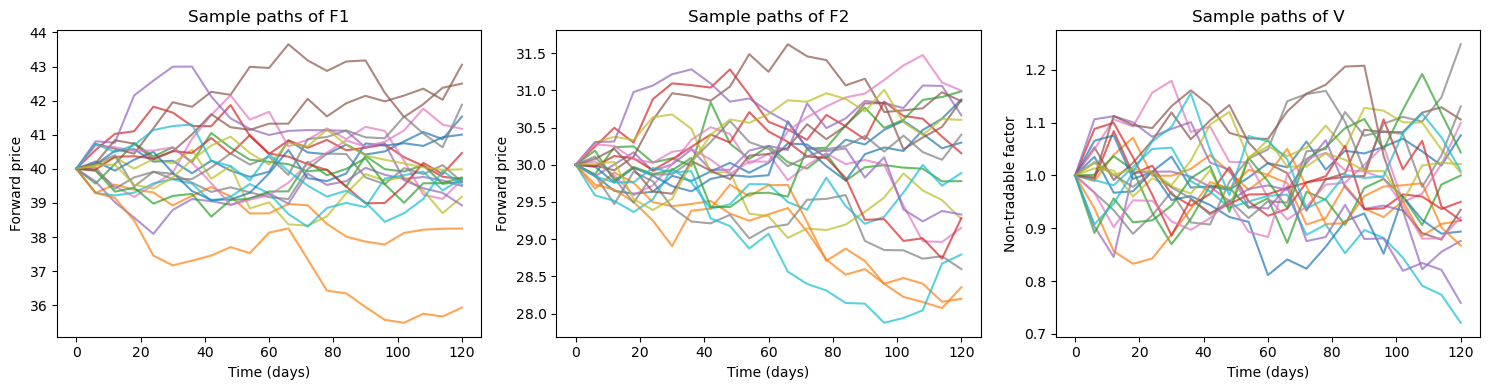

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(20):
    axes[0].plot(time_days, tradable_paths[i, :, 0], alpha=0.7)
axes[0].set_title("Sample paths of F1")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Forward price")

for i in range(20):
    axes[1].plot(time_days, tradable_paths[i, :, 1], alpha=0.7)
axes[1].set_title("Sample paths of F2")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Forward price")

for i in range(20):
    axes[2].plot(time_days, volume_paths[i, :], alpha=0.7)
axes[2].set_title("Sample paths of V")
axes[2].set_xlabel("Time (days)")
axes[2].set_ylabel("Non-tradable factor")

plt.tight_layout()
plt.show()


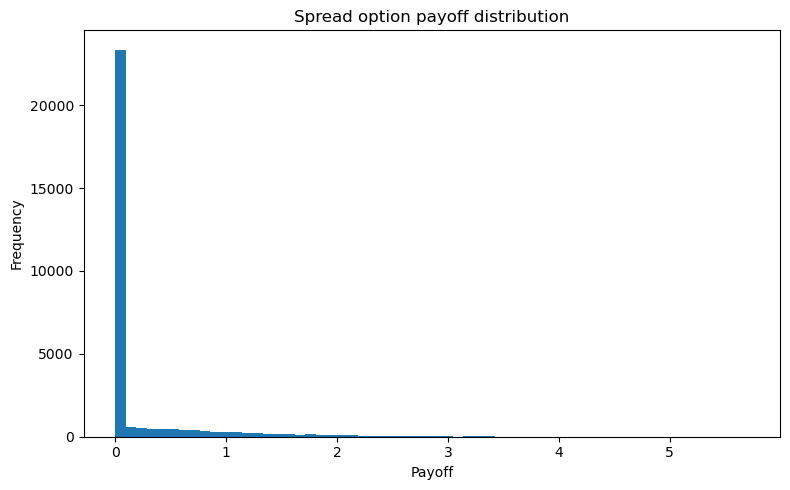

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(payoff, bins=60)
plt.title("Spread option payoff distribution")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Interface specification

The expected model output is the matrix of hedging positions for the tradable assets.

For a split with `n_paths` trajectories, `N` hedging dates and `d=2` tradable assets,
the expected shape is `(n_paths, N, 2)`.

The element `hedges[i, t, j]` is the position held in tradable asset `j`
on the interval `[t, t+1]` for trajectory `i`.


In [11]:
INTERFACE = {
    "expected_shape": "(n_paths, N, 2)",
    "convention": "hedges[i, t, j] is the position in tradable asset j held on interval [t, t+1] for path i",
    "recommended_files": [
        "hedges_base_test.npy",
        "hedges_asymmetric_loss_test.npy",
        "hedges_transaction_cost_test.npy"
    ],
    "liquidity_constraint": "positions and position increments must satisfy the liquidity bounds stored in config['liquidity']"
}

with open(BASE_DIR / "interface_spec.json", "w", encoding="utf-8") as f:
    json.dump(INTERFACE, f, indent=2)

INTERFACE


{'expected_shape': '(n_paths, N, 2)',
 'convention': 'hedges[i, t, j] is the position in tradable asset j held on interval [t, t+1] for path i',
 'recommended_files': ['hedges_base_test.npy',
  'hedges_asymmetric_loss_test.npy',
  'hedges_transaction_cost_test.npy'],
 'liquidity_constraint': "positions and position increments must satisfy the liquidity bounds stored in config['liquidity']"}

## Financial evaluation pipeline

The functions below evaluate any hedging strategy produced later by the learning model.
Liquidity constraints are checked before computing performance metrics.


In [12]:
def validate_hedges_shape(tradable_paths, hedges):
    n_paths, n_steps_plus_one, d = tradable_paths.shape
    expected_shape = (n_paths, n_steps_plus_one - 1, d)
    if hedges.shape != expected_shape:
        raise ValueError(f"Expected hedges shape {expected_shape}, got {hedges.shape}")


def check_liquidity_constraints(hedges, liquidity):
    liquidity = np.asarray(liquidity, dtype=float)
    if np.any(np.abs(hedges[:, 0, :]) > liquidity + 1e-12):
        raise ValueError("Initial hedge positions violate liquidity constraints.")
    increments = np.diff(hedges, axis=1)
    if np.any(np.abs(increments) > liquidity + 1e-12):
        raise ValueError("Hedge increments violate liquidity constraints.")


def compute_terminal_portfolio_value(tradable_paths, hedges, premium=0.0):
    validate_hedges_shape(tradable_paths, hedges)
    increments = tradable_paths[:, 1:, :] - tradable_paths[:, :-1, :]
    gains = np.sum(hedges * increments, axis=(1, 2))
    return premium + gains


def compute_transaction_costs(hedges, transaction_costs):
    transaction_costs = np.asarray(transaction_costs, dtype=float)
    first_trade = np.abs(hedges[:, 0, :])
    later_trades = np.abs(np.diff(hedges, axis=1))
    all_trades = np.concatenate([first_trade[:, None, :], later_trades], axis=1)
    return np.sum(all_trades * transaction_costs[None, None, :], axis=(1, 2))


def compute_hedging_error(tradable_paths, hedges, payoff, premium=0.0):
    terminal_value = compute_terminal_portfolio_value(tradable_paths, hedges, premium=premium)
    return terminal_value - payoff


def compute_net_pnl(tradable_paths, hedges, payoff, premium=0.0, transaction_costs=None):
    terminal_value = compute_terminal_portfolio_value(tradable_paths, hedges, premium=premium)
    costs = 0.0
    if transaction_costs is not None:
        costs = compute_transaction_costs(hedges, transaction_costs)
    return terminal_value - payoff - costs


def summarize_array(x):
    return {
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "min": float(np.min(x)),
        "q01": float(np.quantile(x, 0.01)),
        "q05": float(np.quantile(x, 0.05)),
        "median": float(np.median(x)),
        "q95": float(np.quantile(x, 0.95)),
        "q99": float(np.quantile(x, 0.99)),
        "max": float(np.max(x)),
    }


def print_summary(name, x):
    summary = summarize_array(x)
    print(name)
    for key, value in summary.items():
        print(f"  {key}: {value:.6f}")
    return summary


## Dummy strategy test

This validates the evaluation pipeline before any model output is available.
The dummy strategy is the zero-hedge strategy.


In [13]:
test_tradable = dataset["test"]["tradable_paths"]
test_payoff = dataset["test"]["payoff"]

n_test_paths, n_steps_plus_one, d = test_tradable.shape
N = n_steps_plus_one - 1

dummy_hedges = np.zeros((n_test_paths, N, d), dtype=np.float64)

check_liquidity_constraints(dummy_hedges, CONFIG["liquidity"])

dummy_error = compute_hedging_error(
    tradable_paths=test_tradable,
    hedges=dummy_hedges,
    payoff=test_payoff,
    premium=0.0
)

dummy_net_pnl = compute_net_pnl(
    tradable_paths=test_tradable,
    hedges=dummy_hedges,
    payoff=test_payoff,
    premium=0.0,
    transaction_costs=CONFIG["transaction_costs"]
)

summary_error = print_summary("Dummy hedging error", dummy_error)
summary_net_pnl = print_summary("Dummy net PnL", dummy_net_pnl)


Dummy hedging error
  mean: -0.216662
  std: 0.544795
  min: -4.543742
  q01: -2.511688
  q05: -1.394191
  median: 0.000000
  q95: 0.000000
  q99: 0.000000
  max: 0.000000
Dummy net PnL
  mean: -0.216662
  std: 0.544795
  min: -4.543742
  q01: -2.511688
  q05: -1.394191
  median: 0.000000
  q95: 0.000000
  q99: 0.000000
  max: 0.000000


In [14]:
with open(RESULTS_DIR / "dummy_hedging_error_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_error, f, indent=2)

with open(RESULTS_DIR / "dummy_net_pnl_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_net_pnl, f, indent=2)

np.save(RESULTS_DIR / "dummy_hedging_error.npy", dummy_error)
np.save(RESULTS_DIR / "dummy_net_pnl.npy", dummy_net_pnl)

print(f"Dummy evaluation saved in: {RESULTS_DIR.resolve()}")


Dummy evaluation saved in: C:\Users\nguem\Documents\ISE_3\ISE_3\M2_SFA\SEM_II\ml_finance\projet\git\Machine-Learning-in-Finance-Project\deep_hedging_phase1_paper_aligned\results


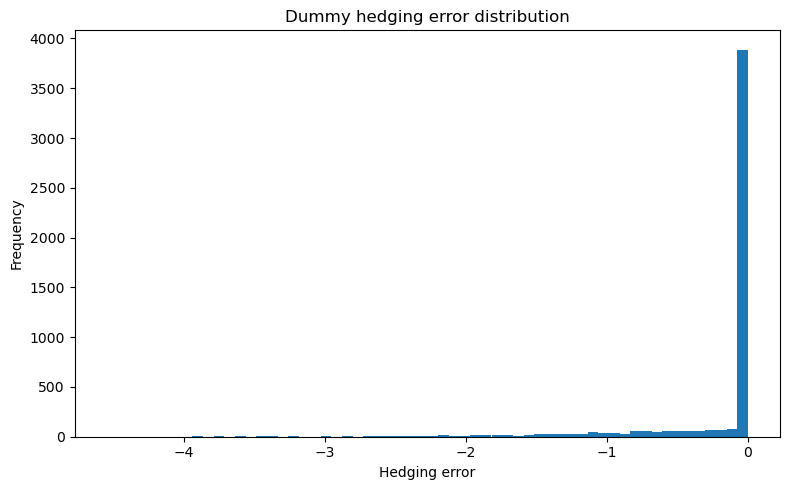

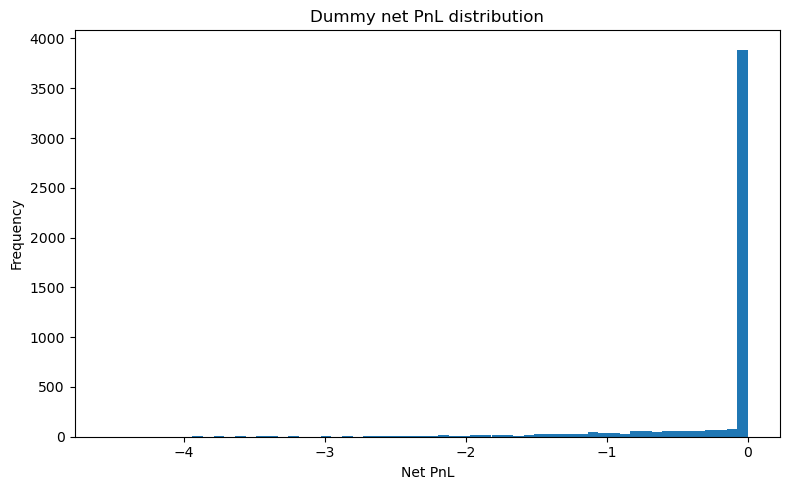

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(dummy_error, bins=60)
plt.title("Dummy hedging error distribution")
plt.xlabel("Hedging error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(dummy_net_pnl, bins=60)
plt.title("Dummy net PnL distribution")
plt.xlabel("Net PnL")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Final note

At this stage, the phase 1 dataset is ready and aligned with the paper structure.
The evaluation framework is also ready.
The next step is to plug model-generated hedging strategies into this pipeline.
